In [4]:
#TASK - 1

import pandas as pd
df = pd.read_csv("Housing.csv")

print("First 10 Rows:")
print(df.head(10))

print("\nDataset Shape:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

target = "price"
features = [col for col in df.columns if col != target]
print("\nTarget Column:")
print(target)
print("\nFeature Columns:")
print(features)

print("\nMissing Values:")
print(df.isnull().sum())

First 10 Rows:
      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes

In [5]:
#TASK - 2

print(df.isnull().sum())

print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

df_encoded = pd.get_dummies(df,
    columns=[
        'mainroad',
        'guestroom',
        'basement',
        'hotwaterheating',
        'airconditioning',
        'prefarea',
        'furnishingstatus'
    ],
    drop_first=True)

X = df_encoded.drop('price', axis=1)
y = df_encoded['price']
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

df_encoded.head()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
Duplicates: 0
Features Shape: (545, 13)
Target Shape: (545,)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [6]:
#TASK - 3

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

X = df_encoded.drop("price", axis=1)
y = df_encoded["price"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)


# Linear Regression Model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2_lr = r2_score(y_test, y_pred_lr)


# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)


# Model Comparison
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R² Score": [r2_lr, r2_rf]})

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)
print("\nModel Performance Comparison")
print(comparison)

Training Set Shape: (436, 13)
Testing Set Shape: (109, 13)

Model Performance Comparison
               Model           MAE          RMSE  R² Score
0  Linear Regression  9.700434e+05  1.324507e+06  0.652924
1      Random Forest  1.021546e+06  1.400566e+06  0.611919


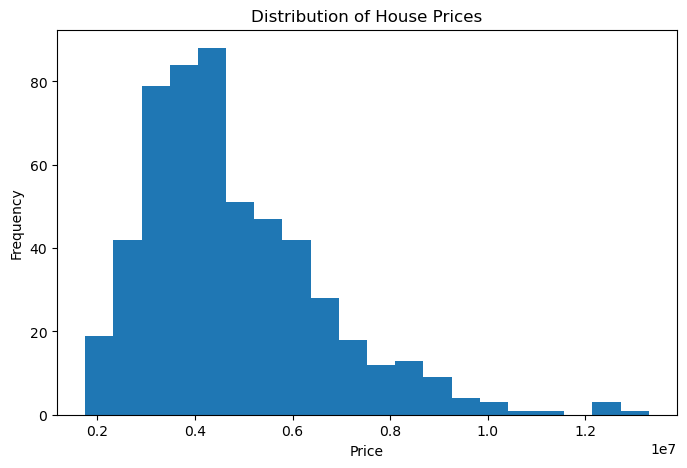

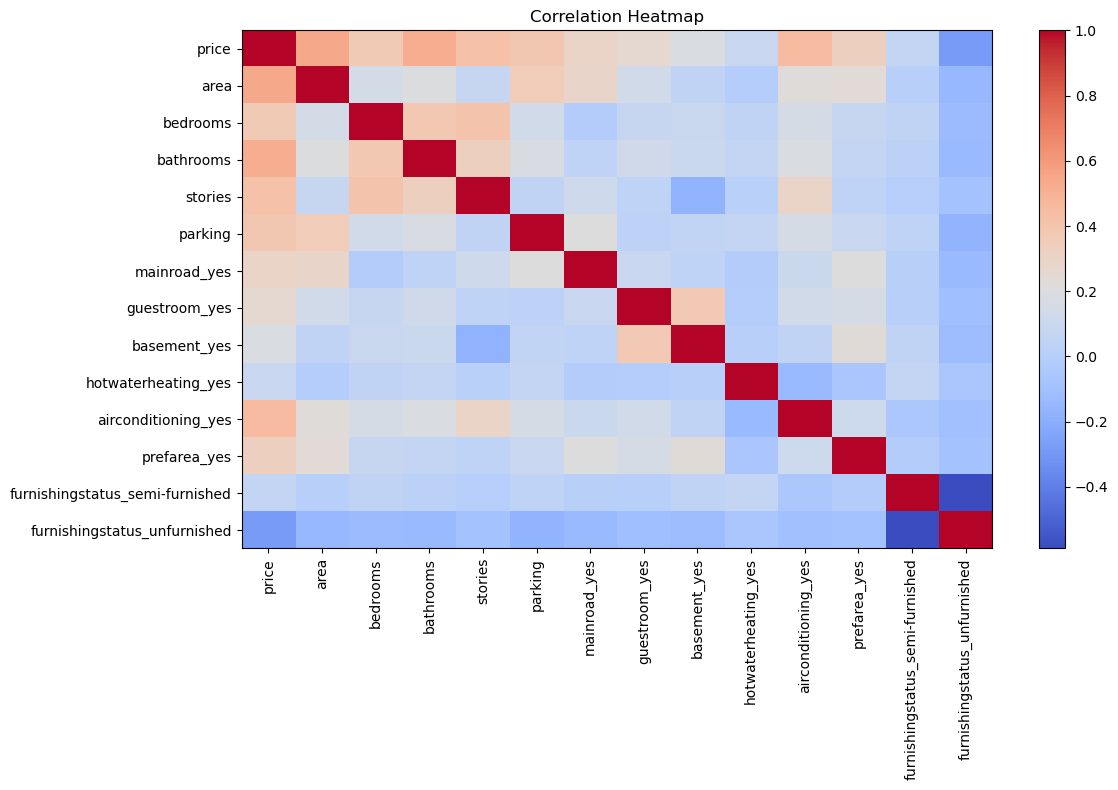

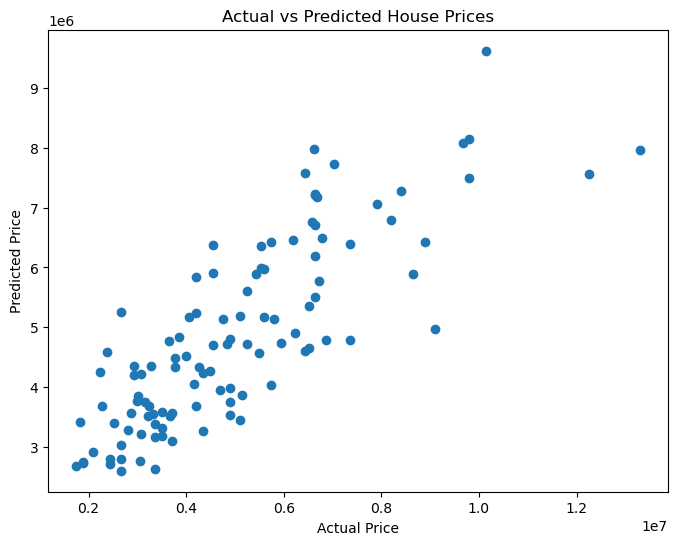

In [7]:
#TASK - 4

import matplotlib.pyplot as plt

# Chart 1: Histogram
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=20)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# Chart 2: Heatmap
corr_matrix = df_encoded.corr()
plt.figure(figsize=(12,8))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)),
           corr_matrix.columns,
           rotation=90)
plt.yticks(range(len(corr_matrix.columns)),
           corr_matrix.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Chart 3: Actual vs Predicted
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

#TASK - 5

# Insights & Summary

**1. Features Influencing House Price:** 
Based on the correlation analysis, features such as **area, bathrooms, stories, and air conditioning** showed a stronger influence on house prices compared to other features.

**2. Model Accuracy:**  
The **Linear Regression model** performed slightly better than the Random Forest model with an **R² score of 0.65**. This means the model was able to explain about **65% of the variation** in house prices, indicating a reasonably good level of accuracy.

**3. Interesting Observation:**  
One surprising finding was that features such as **parking and guest room availability** had a weaker impact on house prices than expected, while factors like area and air conditioning were more influential.

**4. Model Comparison:**  
Although Random Forest is generally expected to perform better, in this dataset **Linear Regression achieved better results**, making it the preferred model for this analysis.

**5. Recommendation for Real Estate Business:**  
Real estate businesses should focus on properties with **larger areas, more bathrooms, better amenities, and air conditioning**, as these features appear to contribute significantly to higher property values.